LFC columns: ['log2FoldChange_rep1', 'log2FoldChange_rep2', 'log2FoldChange_rep3']
SE columns: ['lfcSE_rep1', 'lfcSE_rep2', 'lfcSE_rep3']


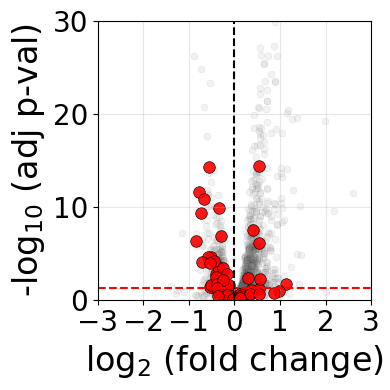


Number of stop_codon controls: 77


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

# Load data
df1 = pd.read_csv('/../../Data/Figure_5/sequencing_data_all.csv')

# Identify columns for reps 1-3
lfc_cols = sorted([c for c in df1.columns if c.startswith('log2FoldChange_rep') 
                   and c[-1] in ['1', '2', '3']])
se_cols = sorted([c for c in df1.columns if c.startswith('lfcSE_rep') 
                  and c[-1] in ['1', '2', '3']])

print(f"LFC columns: {lfc_cols}")
print(f"SE columns: {se_cols}")

# Extract data
lfc_data = df1[lfc_cols].values
se_data = df1[se_cols].values

# Calculate inverse-variance weights
weights = 1 / (se_data ** 2)

# Weighted mean LFC
weighted_lfc = np.nansum(weights * lfc_data, axis=1) / np.nansum(weights, axis=1)

# Pooled SE of weighted mean
pooled_se = 1 / np.sqrt(np.nansum(weights, axis=1))

# Z-score and p-values
z_scores = weighted_lfc / pooled_se
pvalues = 2 * stats.norm.sf(np.abs(z_scores))

# Add to dataframe
df1['weighted_log2FC'] = weighted_lfc
df1['pooled_SE'] = pooled_se
df1['z_score'] = z_scores
df1['pvalue'] = pvalues

# Multiple testing correction
valid_mask = np.isfinite(df1['pvalue'])
_, padj_values, _, _ = multipletests(df1.loc[valid_mask, 'pvalue'], method='fdr_bh')
df1['padj'] = np.nan
df1.loc[valid_mask, 'padj'] = padj_values
df1['neg_log10_padj'] = -np.log10(df1['padj'])

# Identify stop_codon controls
stop_codon = df1[df1['Sequence_ID'].str.endswith('_early_stop')].copy()
others = df1[~df1['Sequence_ID'].str.endswith('_early_stop')].copy()

# --- Volcano Plot ---
fig, ax = plt.subplots(figsize=[4, 4])

# Plot everything else in grey (background, faded)
ax.scatter(others['weighted_log2FC'], others['neg_log10_padj'], alpha=0.10, s=25,
           c='grey', edgecolors='k', linewidths=0.3)

# Plot stop_codon sequences on top in red
ax.scatter(stop_codon['weighted_log2FC'], stop_codon['neg_log10_padj'], alpha=0.9, s=70,
           c='red', edgecolors='k', linewidths=0.5, label=f'Stop codon controls (n={len(stop_codon)})')

# Add horizontal line at -log10(0.05)
ax.axhline(y=-np.log10(0.05), color='red', linestyle='--', linewidth=1.5)

# Add vertical line at 0
ax.axvline(x=0, color='k', linestyle='--', linewidth=1.5)

ax.set_xlabel('log$_2$ (fold change)', fontsize=24)
ax.set_ylabel('-log$_{10}$ (adj p-val)', fontsize=24)
ax.grid(True, alpha=0.3)
ax.set_xlim(-3, 3)
ax.set_ylim(0, 30)
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.tick_params(axis='both', which='major', labelsize=20)

plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
#plt.savefig('volcano_plot_stop_codon_weighted.svg', format='svg', bbox_inches='tight')
plt.show()

# Print counts and breakdown
print(f"\nNumber of stop_codon controls: {len(stop_codon)}")